# Exploratory Data Analysis - ReviewInsight

This notebook performs comprehensive exploratory data analysis on the Amazon product reviews dataset.

## Objectives
- Understand the distribution of ratings
- Analyze review length patterns
- Explore category-wise sentiment breakdown
- Identify temporal trends
- Detect outliers and data quality issues


In [4]:
import sys
import os
from pathlib import Path
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from preprocessing import load_amazon_reviews, preprocess_data

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Set random seed for reproducibility
np.random.seed(42)


## Step 1: Load and Preprocess Data


In [5]:
# Load data (or use preprocessed if available)
data_path = Path("../data/processed/amazon_reviews_processed.parquet")

if data_path.exists():
    print("Loading preprocessed data...")
    df = pd.read_parquet(data_path)
else:
    print("Loading and preprocessing data...")
    df_raw = load_amazon_reviews(n_samples=200000, random_state=42)
    df = preprocess_data(df_raw, save_processed=True)

print(f"\nDataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()


Loading preprocessed data...

Dataset shape: (1000, 8)

Columns: ['review_text', 'star_rating', 'product_category', 'review_date', 'review_text_clean', 'review_length', 'review_year', 'review_month']

First few rows:


,review_text,star_rating,product_category,review_date,review_text_clean,review_length,review_year,review_month
0,I bought my ironing board at Target a long tim...,5,unknown,2025-12-25 23:38:05.284101,i bought my ironing board at target a long tim...,77,2025,12
1,"With Redwall, my experience is that you get in...",5,unknown,2025-12-25 23:38:05.284101,with redwall my experience is that you get int...,108,2025,12
2,I read this book more times than I care to adm...,5,unknown,2025-12-25 23:38:05.284101,i read this book more times than i care to adm...,47,2025,12
3,"I have re-bought this product, since the first...",5,unknown,2025-12-25 23:38:05.284101,i have re bought this product since the first ...,64,2025,12
4,I have a Gripmaster that I bought probably 6 y...,1,unknown,2025-12-25 23:38:05.284101,i have a gripmaster that i bought probably 6 y...,132,2025,12


## Step 2: Rating Distribution Analysis


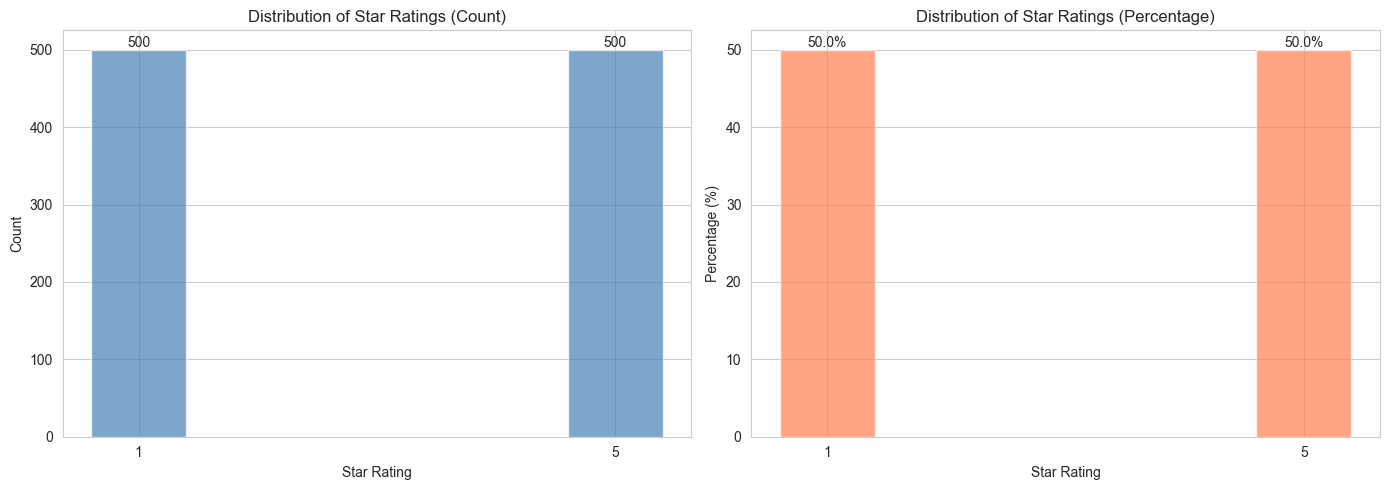

Rating Distribution Summary:
star_rating
1    500
5    500
Name: count, dtype: int64

Percentage Distribution:
star_rating
1    50.0
5    50.0
Name: proportion, dtype: float64


In [6]:
# Rating distribution
rating_counts = df['star_rating'].value_counts().sort_index()
rating_pct = df['star_rating'].value_counts(normalize=True).sort_index() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
ax1.bar(rating_counts.index, rating_counts.values, color='steelblue', alpha=0.7)
ax1.set_xlabel('Star Rating')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Star Ratings (Count)')
ax1.set_xticks(rating_counts.index)
for i, v in enumerate(rating_counts.values):
    ax1.text(rating_counts.index[i], v, str(v), ha='center', va='bottom')

# Percentage plot
ax2.bar(rating_pct.index, rating_pct.values, color='coral', alpha=0.7)
ax2.set_xlabel('Star Rating')
ax2.set_ylabel('Percentage (%)')
ax2.set_title('Distribution of Star Ratings (Percentage)')
ax2.set_xticks(rating_pct.index)
for i, v in enumerate(rating_pct.values):
    ax2.text(rating_pct.index[i], v, f'{v:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../outputs/figures/rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Rating Distribution Summary:")
print(rating_counts)
print(f"\nPercentage Distribution:")
print(rating_pct.round(2))


### Insights:
- Most reviews are positive (4-5 stars), indicating a positive bias in the dataset
- This class imbalance will need to be addressed during modeling


## Step 3: Review Length Analysis


Review Length Statistics by Rating:
             count    mean        std   min   25%   50%     75%    max
star_rating                                                           
1            500.0  78.286  43.324661  10.0  41.0  70.0  108.25  188.0
5            500.0  73.368  42.346086   7.0  38.0  66.0  104.25  183.0


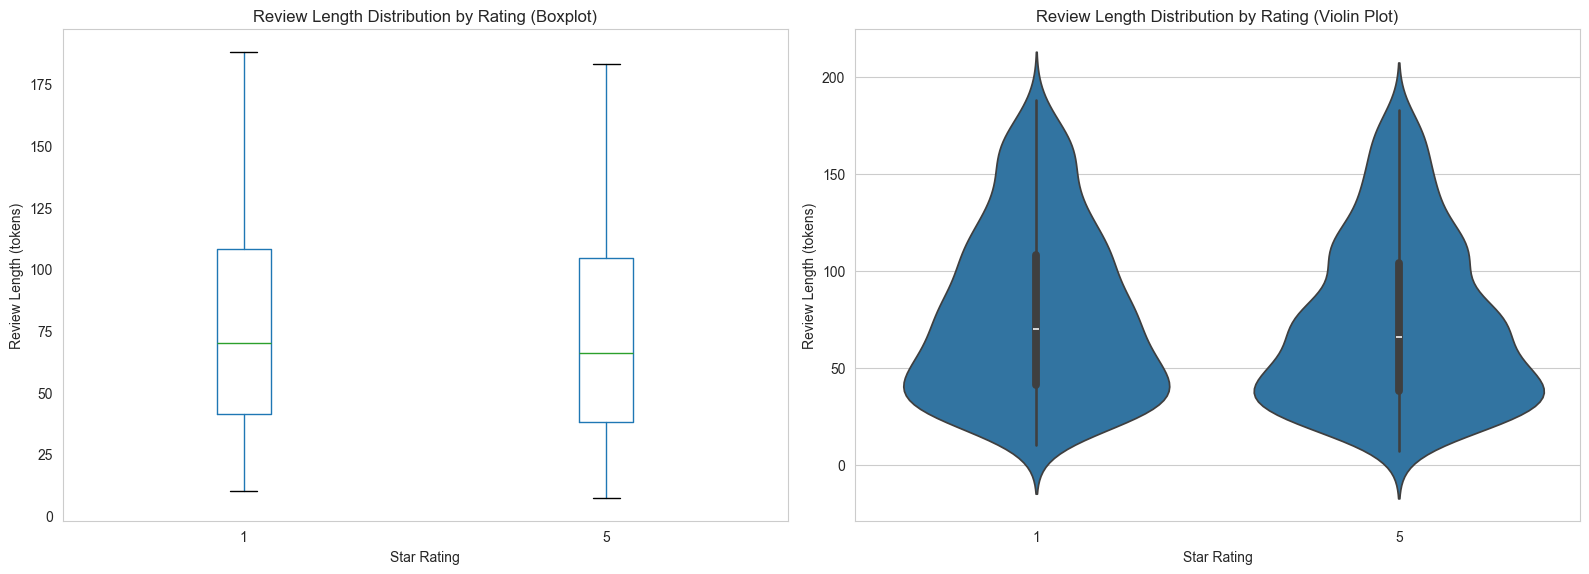

In [7]:
# Review length statistics by rating
length_stats = df.groupby('star_rating')['review_length'].describe()
print("Review Length Statistics by Rating:")
print(length_stats)

# Boxplot: Review length vs rating
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
df.boxplot(column='review_length', by='star_rating', ax=ax1, grid=False)
ax1.set_xlabel('Star Rating')
ax1.set_ylabel('Review Length (tokens)')
ax1.set_title('Review Length Distribution by Rating (Boxplot)')
plt.suptitle('')  # Remove default title

# Violin plot
sns.violinplot(data=df, x='star_rating', y='review_length', ax=ax2)
ax2.set_xlabel('Star Rating')
ax2.set_ylabel('Review Length (tokens)')
ax2.set_title('Review Length Distribution by Rating (Violin Plot)')

plt.tight_layout()
plt.savefig('../outputs/figures/review_length_by_rating.png', dpi=300, bbox_inches='tight')
plt.show()


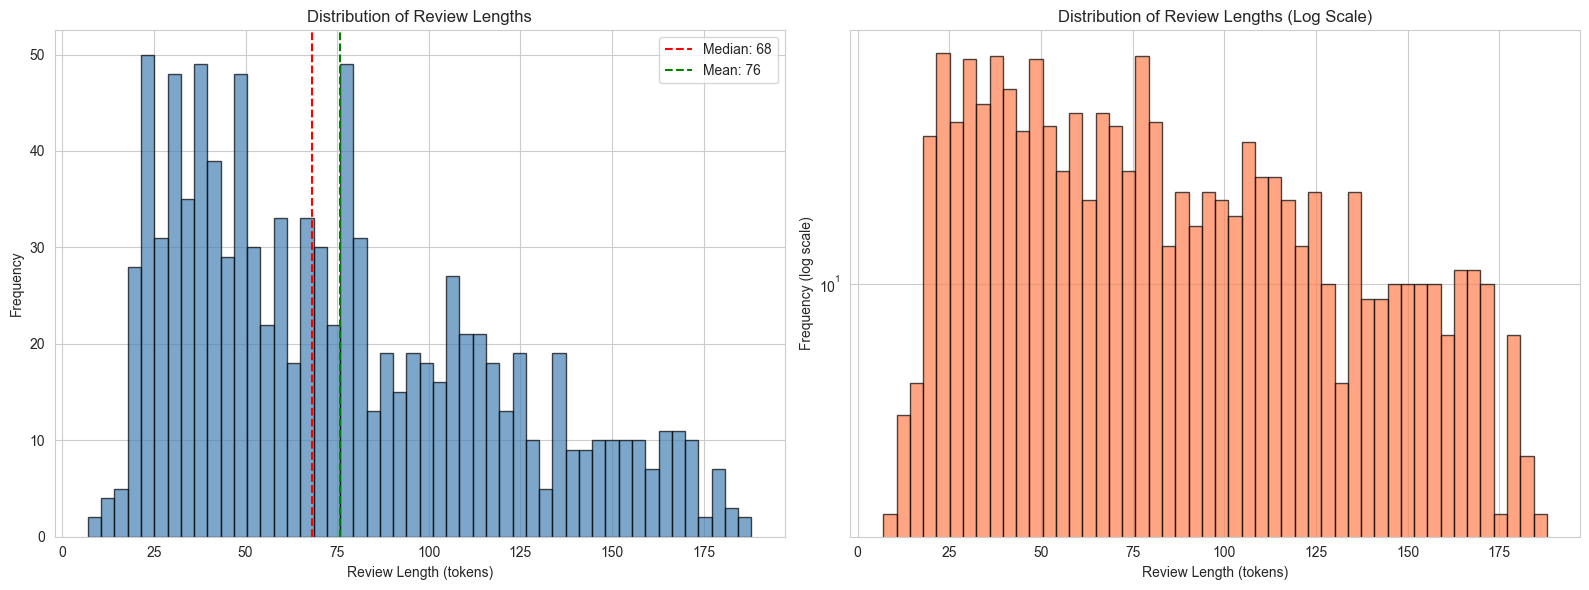


Review Length Statistics:
count    1000.000000
mean       75.827000
std        42.887345
min         7.000000
25%        39.000000
50%        68.000000
75%       107.000000
max       188.000000
Name: review_length, dtype: float64


In [8]:
# Overall review length distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
ax1.hist(df['review_length'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Review Length (tokens)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Review Lengths')
ax1.axvline(df['review_length'].median(), color='red', linestyle='--', 
            label=f'Median: {df["review_length"].median():.0f}')
ax1.axvline(df['review_length'].mean(), color='green', linestyle='--', 
            label=f'Mean: {df["review_length"].mean():.0f}')
ax1.legend()

# Log scale histogram (to see distribution better)
ax2.hist(df['review_length'], bins=50, color='coral', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Review Length (tokens)')
ax2.set_ylabel('Frequency (log scale)')
ax2.set_yscale('log')
ax2.set_title('Distribution of Review Lengths (Log Scale)')

plt.tight_layout()
plt.savefig('../outputs/figures/review_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nReview Length Statistics:")
print(df['review_length'].describe())


### Insights:
- Review lengths vary significantly across ratings
- Negative reviews (1-2 stars) tend to be longer, possibly indicating more detailed complaints
- Positive reviews (4-5 stars) may be shorter, expressing satisfaction concisely


## Step 4: Category-wise Sentiment Breakdown


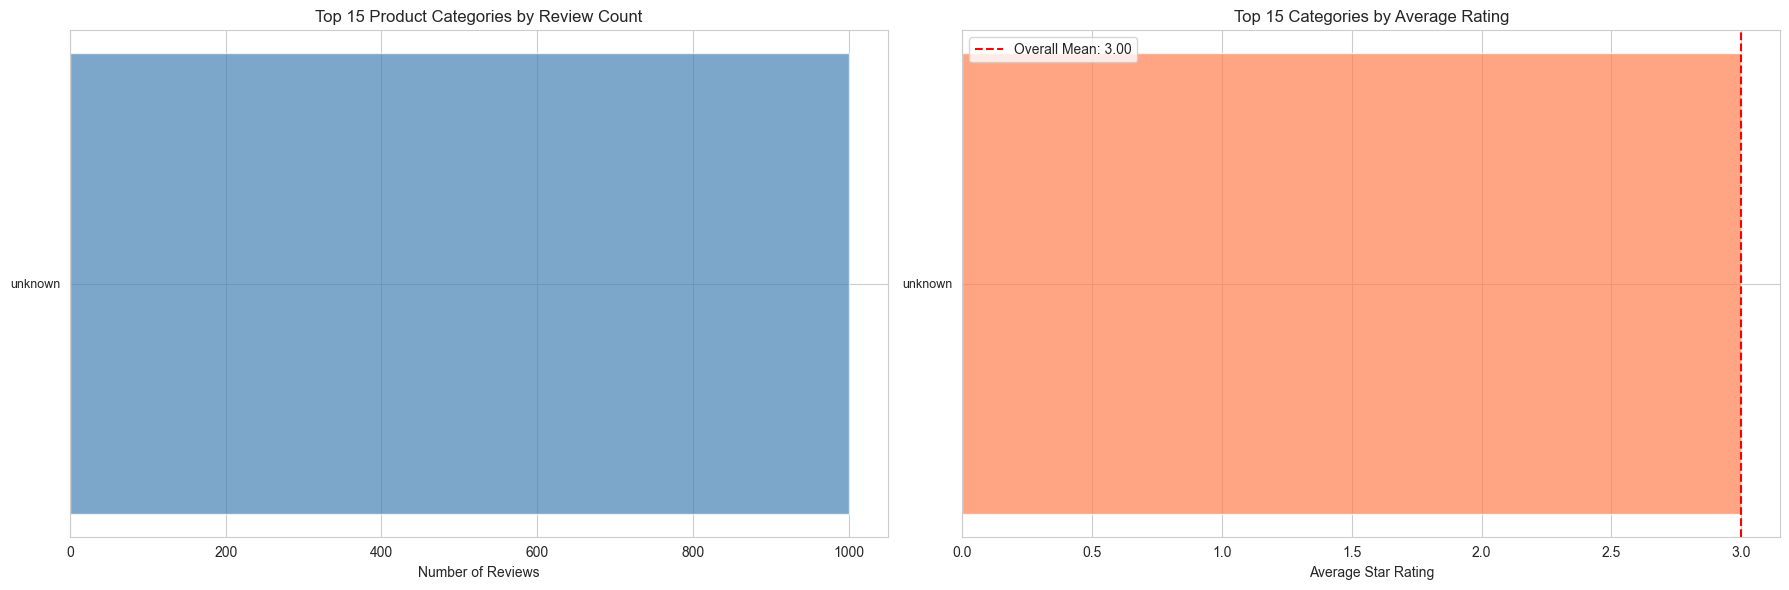


Total number of categories: 1

Top 10 categories by count:
product_category
unknown    1000
Name: count, dtype: int64


In [9]:
# Category analysis
if 'product_category' in df.columns:
    # Top categories by count
    top_categories = df['product_category'].value_counts().head(15)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    
    # Category counts
    ax1.barh(range(len(top_categories)), top_categories.values, color='steelblue', alpha=0.7)
    ax1.set_yticks(range(len(top_categories)))
    ax1.set_yticklabels(top_categories.index, fontsize=9)
    ax1.set_xlabel('Number of Reviews')
    ax1.set_title('Top 15 Product Categories by Review Count')
    ax1.invert_yaxis()
    
    # Average rating by category (for top categories)
    category_ratings = df.groupby('product_category')['star_rating'].mean().sort_values(ascending=False).head(15)
    ax2.barh(range(len(category_ratings)), category_ratings.values, color='coral', alpha=0.7)
    ax2.set_yticks(range(len(category_ratings)))
    ax2.set_yticklabels(category_ratings.index, fontsize=9)
    ax2.set_xlabel('Average Star Rating')
    ax2.set_title('Top 15 Categories by Average Rating')
    ax2.invert_yaxis()
    ax2.axvline(df['star_rating'].mean(), color='red', linestyle='--', 
                 label=f'Overall Mean: {df["star_rating"].mean():.2f}')
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/category_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nTotal number of categories: {df['product_category'].nunique()}")
    print(f"\nTop 10 categories by count:")
    print(top_categories.head(10))
else:
    print("Product category column not found in dataset")


## Step 5: Temporal Trends Analysis


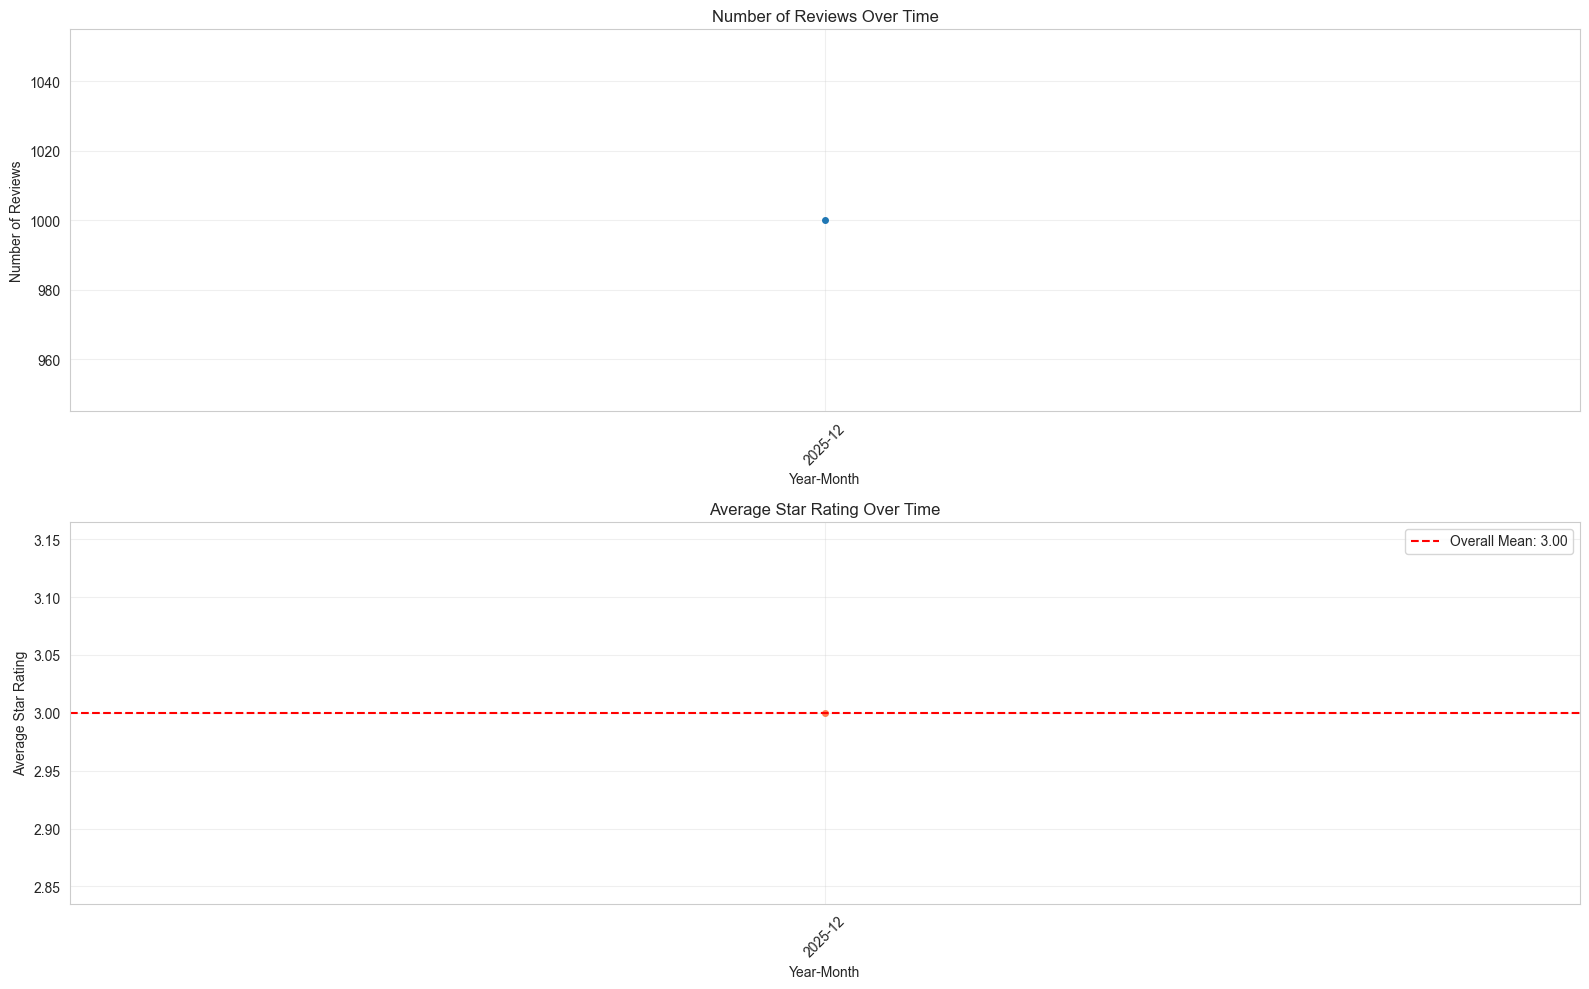


Date range: 2025-12-25 23:38:05.284101 to 2025-12-25 23:38:05.284101

Monthly review counts (last 12 months):
year_month
2025-12    1000
Freq: M, dtype: int64


In [10]:
# Temporal analysis
if 'review_date' in df.columns and df['review_date'].notna().sum() > 0:
    # Convert to datetime if not already
    df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')
    df_temporal = df[df['review_date'].notna()].copy()
    
    # Group by year-month
    df_temporal['year_month'] = df_temporal['review_date'].dt.to_period('M')
    
    # Time series plots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
    
    # Review count over time
    monthly_counts = df_temporal.groupby('year_month').size()
    ax1.plot(monthly_counts.index.astype(str), monthly_counts.values, marker='o', linewidth=2, markersize=4)
    ax1.set_xlabel('Year-Month')
    ax1.set_ylabel('Number of Reviews')
    ax1.set_title('Number of Reviews Over Time')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(alpha=0.3)
    
    # Average rating over time
    monthly_ratings = df_temporal.groupby('year_month')['star_rating'].mean()
    ax2.plot(monthly_ratings.index.astype(str), monthly_ratings.values, marker='o', 
             linewidth=2, markersize=4, color='coral')
    ax2.axhline(df['star_rating'].mean(), color='red', linestyle='--', 
                label=f'Overall Mean: {df["star_rating"].mean():.2f}')
    ax2.set_xlabel('Year-Month')
    ax2.set_ylabel('Average Star Rating')
    ax2.set_title('Average Star Rating Over Time')
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/temporal_trends.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nDate range: {df_temporal['review_date'].min()} to {df_temporal['review_date'].max()}")
    print(f"\nMonthly review counts (last 12 months):")
    print(monthly_counts.tail(12))
else:
    print("Review date information not available or invalid")


## Step 6: Outlier Detection


Outlier Detection (IQR method):
  Lower bound: -63 tokens
  Upper bound: 209 tokens
  Number of outliers: 0 (0.00%)

Very short reviews (< 5 tokens): 0 (0.00%)
Very long reviews (> 1000 tokens): 0 (0.00%)


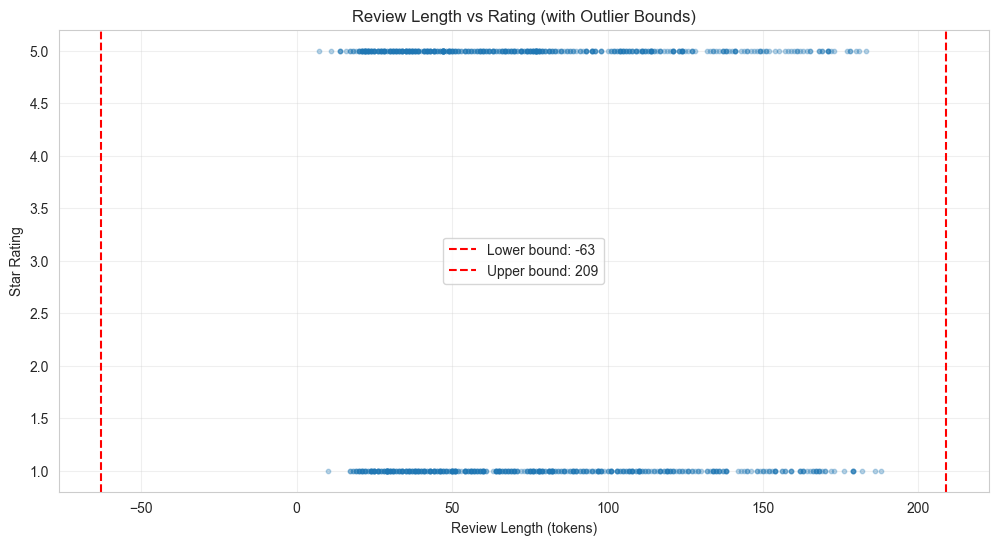


Example very short reviews:
Empty DataFrame
Columns: [review_text_clean, star_rating, review_length]
Index: []

Example very long reviews:
Empty DataFrame
Columns: [review_text_clean, star_rating, review_length]
Index: []


In [11]:
# Identify outliers in review length
Q1 = df['review_length'].quantile(0.25)
Q3 = df['review_length'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['review_length'] < lower_bound) | (df['review_length'] > upper_bound)]
print(f"Outlier Detection (IQR method):")
print(f"  Lower bound: {lower_bound:.0f} tokens")
print(f"  Upper bound: {upper_bound:.0f} tokens")
print(f"  Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

# Very short reviews (potential spam or low quality)
very_short = df[df['review_length'] < 5]
print(f"\nVery short reviews (< 5 tokens): {len(very_short)} ({len(very_short)/len(df)*100:.2f}%)")

# Very long reviews
very_long = df[df['review_length'] > 1000]
print(f"Very long reviews (> 1000 tokens): {len(very_long)} ({len(very_long)/len(df)*100:.2f}%)")

# Visualize outliers
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df['review_length'], df['star_rating'], alpha=0.3, s=10)
ax.axvline(lower_bound, color='red', linestyle='--', label=f'Lower bound: {lower_bound:.0f}')
ax.axvline(upper_bound, color='red', linestyle='--', label=f'Upper bound: {upper_bound:.0f}')
ax.set_xlabel('Review Length (tokens)')
ax.set_ylabel('Star Rating')
ax.set_title('Review Length vs Rating (with Outlier Bounds)')
ax.legend()
ax.grid(alpha=0.3)
plt.savefig('../outputs/figures/outlier_detection.png', dpi=300, bbox_inches='tight')
plt.show()

# Show some example outliers
print("\nExample very short reviews:")
print(very_short[['review_text_clean', 'star_rating', 'review_length']].head(5))
print("\nExample very long reviews:")
print(very_long[['review_text_clean', 'star_rating', 'review_length']].head(5))


## Step 7: Summary and Key Insights

### Key Findings:

1. **Rating Distribution**: The dataset shows a positive bias with most reviews being 4-5 stars. This class imbalance needs to be addressed during modeling.

2. **Review Length Patterns**: 
   - Negative reviews tend to be longer, possibly containing more detailed complaints
   - Positive reviews are often shorter and more concise
   - Review length varies significantly across ratings

3. **Category Analysis**: Different product categories show varying review patterns and average ratings, which could be useful for feature engineering.

4. **Temporal Trends**: Review volume and average ratings may show trends over time, which could indicate seasonal patterns or changes in product quality.

5. **Outliers**: 
   - Very short reviews (< 5 tokens) may be spam or low-quality
   - Very long reviews (> 1000 tokens) are rare but may contain valuable detailed feedback
   - Consider filtering extreme outliers before modeling

### Next Steps:
- Proceed to feature engineering with TF-IDF vectorization
- Create binary sentiment labels (positive >= 4 stars, negative <= 2 stars)
- Address class imbalance in modeling phase
